In [9]:
%load_ext autoreload
%autoreload 2

#import sys
import pandas
#sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt

datadir0  = '/Users/billiemeadowcroft/Dropbox/Collagen/NargessPlotting/GithubCode/Figures/FigAlignment/Data/Remodel_Xstretch100/MergingFiles/'
plotsdir  = '//Users/billiemeadowcroft/Dropbox/Collagen/NargessPlotting/GithubCode/Figures/FigAlignment/Plots/'
clrs = ["black","#c239e8","#1f78b4","#b2df8a","#33a02c"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import re
from pathlib import Path

def read_blocks(fname):
    """
    Yield (timestep:int, lines:list[str]) for each block in the file.
    A block is:
        timestep N
        <zero or more lines until next 'timestep'>
    """
    blocks = []
    current_ts = None
    current_lines = []

    with open(fname, "r") as f:
        for line in f:
            line_stripped = line.strip()
            m = re.match(r"timestep\s+(\d+)", line_stripped, re.IGNORECASE)
            if m:
                # flush previous block
                if current_ts is not None:
                    blocks.append((current_ts, current_lines))
                current_ts = int(m.group(1))
                current_lines = [line]  # keep the original 'timestep ...' line
            else:
                # data line
                if current_ts is not None:
                    current_lines.append(line)
                else:
                    # line before first timestep? skip or keep; here we skip
                    pass

    # flush last block
    if current_ts is not None:
        blocks.append((current_ts, current_lines))

    return blocks


def merge_time_series(infiles, outfile):
    max_ts = -1
    merged_lines = []

    for fname in infiles:
        blocks = read_blocks(fname)
        for ts, lines in blocks:
            if ts > max_ts:
                merged_lines.extend(lines)
                max_ts = ts
            else:
                # overlapping or older timestep → skip
                pass

    with open(outfile, "w") as f:
        f.writelines(merged_lines)
    # set your files here, in chronological order
    

In [22]:
seed = '4'
infiles = [datadir0+"MolAlignrun_seed"+seed+".txt", datadir0+"MolAlignrunRS_seed"+seed+".txt", datadir0+"MolAlignrunRSRS_seed"+seed+".txt", datadir0+"MolAlignrunRSRSRS_seed"+seed+".txt"]
outfile = datadir0+"/merged_seed"+seed+".txt"
merge_time_series(infiles, outfile)
print(f"wrote {outfile}")


wrote /Users/billiemeadowcroft/Dropbox/Collagen/NargessPlotting/GithubCode/Figures/FigAlignment/Data/Remodel_Xstretch100/MergingFiles//merged_seed4.txt


38859000
44515000
46131000
45121000


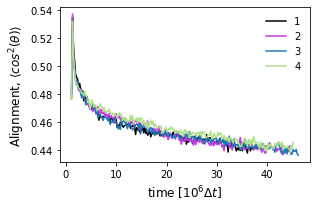

In [23]:
fig,ax= plt.subplots(1,figsize = (4.5,3))
frame = 202000
fs2 = 12
TEq = 1085000
Vol = 164*164*12
TStretch = 1e5
NumMolecules=15680
seeds = '1 2 3 4'.split() #4
for s in range(len(seeds)):
    outfile = datadir0+"/merged_seed"+seeds[s]+".txt"
    tEq_add = TEq
    summingtSq=[]
    datafolder = outfile
    dotX_ = pandas.read_csv(datafolder, sep = ' ', usecols = [0], header =None)
    timesteps1 = int((len(dotX_))/(NumMolecules+1))
    # timestepsEq = int((len(dotX_Eq))/(NumMolecules+1))
    # dotX_Eq__ = np.reshape(dotX_Eq.values,(timestepsEq,-1))
    # dotX_Eq = dotX_Eq__ [:,1:]
    # dotX_EqF = np.abs(dotX_Eq.astype(float))
    dotX__ = np.reshape(dotX_.values,(timesteps1,-1))
    dotX = dotX__ [:,1:]
    dotXF = np.abs(dotX.astype(float))
    time = []
    #timestepsarr = np.arange(timestepsEq)
    #timestepsEqReal = np.multiply(timestepsarr,frame)
    #print("np.max(timestepsEqReal)",np.max(timestepsEqReal),"np.min(timestepsEqReal)",np.min(timestepsEqReal),"TEq",TEq)
    #indexTimeEq  = np.argmin(np.abs(timestepsEqReal - TEq))
    #print("indexTimeEq",indexTimeEq,"len(dotX_EqF)",len(dotX_EqF),"len(dotXF)",len(dotXF),"timesteps1",timesteps1)


    for t in range(timesteps1-1):
        time.append(np.add(np.multiply(t,int(frame)),tEq_add))
        summingtSq.append((np.sum(np.multiply(dotXF[t],dotXF[t]))/NumMolecules))



    ax.plot(np.divide(time,1e6),summingtSq,color = clrs[s],alpha =1,label = seeds[s])
    print(time[-1])
# MolTot.append(summingtSq)
# Times.append(time)
#     max_len = max(len(arr) for arr in MolTot)
#     longest_idx = np.argmax([len(arr) for arr in MolTot])
#     masked = np.ma.empty((len(MolTot), max_len))
#     Time = Times[longest_idx]
#     masked.mask = True  # mask everything by default

#     # Fill in available data for each array
#     for i, arr in enumerate(MolTot):
#         masked[i, :len(arr)] = arr
#         masked.mask[i, :len(arr)] = False  # unmask valid entries

#     MolTotAv = masked.mean(axis=0).filled(np.nan) 
#     MolTotStd = masked.std(axis=0).filled(np.nan)
#     time = Times[longest_idx]
#     ax.plot(np.divide(time,1e6),MolTotAv,color = clrs[ff],linewidth = 2.5,label = labels[ff])
#     ax.fill_between(np.divide(time,1e6),np.subtract(MolTotAv,MolTotStd),np.add(MolTotAv,MolTotStd),color = clrs[ff],alpha = 0.2)

ax.set_xlabel(r"time [$10^6\Delta t$]",fontsize =fs2)
ax.set_ylabel(r'Alignment, $\langle cos^{2}(\theta)\rangle$',fontsize =fs2)
#ax.set_xlim([0.2,20])
#ax.set_ylim([0.33,0.6])
ax.legend(frameon=False)
fig.tight_layout()
#fig.savefig(plotsdir+'MolAlign_NoRemodelVsNoStretch.pdf')
#ax[1].set_xlim([0.5,5])
